In [403]:
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

from utils import *

from qutip import Qobj, basis, expect, ket2dm, mesolve, qeye, tensor
from quaccatoo import NV, PulsedSim, Rabi, QSys
from utils import (
    extract_ancilla_coefficients,
    plot_energy_level_diagram,
    plot_rf_dressing_comparison,
    plot_rabi_diagnostics,
    plot_tripod_leakage,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

In [404]:
# Global Variables

# NV System
B0_mT = 20.0

# RF Dressing
OMEGA_RF_MHZ = 1.5 # the driving amplitude of the RF pulses
DETUNINGS_MHZ = np.zeros(3) # the detuning frequencies in intra-state mixing, manifests as diagonal elements in the RF ham
RF_PHASES = np.array([0., 0.]) # the phases for each of the two RF tones in order e-<->e0 and e0<->e+

# MW Pulses
MW_PHASES = np.array([0., 0., 0.]) # the phases for each of the three MW tones in order (-, 0, +)
TARGET_MW_LEG_MHZ = 0.005
MW_RABI_MHZ = 2 * TARGET_MW_LEG_MHZ

# INITIAL_STATE = g_minus # given later in the code

# Simulation Parameters
rf_loop_ramp_us = 4. # time it takes for the rf to ramp up or down
rf_settle_us = 2.0 # time after the rf is fully turned on before mw pulses begin
mw_loop_ramp_us = 50.0 # time it takes for mw pulses to ramp up or down
mw_pulse_spacing_us = 2.0 # time between mw pulses
berry_loop_duration_us = 40.0 # time duration for each loop
loop_reporting_step_us = 0.5 # time between each hamiltonian propagating step

t_rf_ramp_start_us = 0.0 # start of rf ramp
t_rf_on_us = t_rf_ramp_start_us + rf_loop_ramp_us # rf start ramp time
t_mw1_ramp_start_us = t_rf_on_us + rf_settle_us # time when first mw starts
t_mw2_ramp_start_us = t_mw1_ramp_start_us + mw_pulse_spacing_us # time when second mw starts ramping
t_mw3_ramp_start_us = t_mw2_ramp_start_us + mw_pulse_spacing_us # time when third mw starts ramping
t_loop_1_start_us = t_mw3_ramp_start_us + mw_loop_ramp_us # beginning of loop 1
t_loop_2_start_us = t_loop_1_start_us + berry_loop_duration_us # beginning of loop 2
t_mw_ramp_down_start_us = t_loop_2_start_us + berry_loop_duration_us # ramp down mws all at the same time
t_mw_zero_us = t_mw_ramp_down_start_us + mw_loop_ramp_us # time when mw pulses have ramped down and are now zero
t_rf_ramp_down_start_us = t_mw_zero_us
TOTAL_TIME_US = t_rf_ramp_down_start_us + rf_loop_ramp_us # total time of simulation in microseconds

SIMULATION_TIME = np.arange(0, TOTAL_TIME_US + loop_reporting_step_us, loop_reporting_step_us) # resolves the remaining MHz-scale rotating-frame dynamics

# NOTE : ensure there is enough time for all mws to ramp on before loops start
assert t_mw1_ramp_start_us + mw_loop_ramp_us <= t_loop_1_start_us
assert t_mw2_ramp_start_us + mw_loop_ramp_us <= t_loop_1_start_us
assert t_mw3_ramp_start_us + mw_loop_ramp_us <= t_loop_1_start_us

# diagnostic variables
t_mw1_on_us = t_mw_ramp_down_start_us - t_mw1_ramp_start_us # total time the first mw is fully on
t_mw2_on_us = t_mw_ramp_down_start_us - t_mw2_ramp_start_us # total time the second mw is fully on
t_mw3_on_us = t_mw_ramp_down_start_us - t_mw3_ramp_start_us # total time the third mw is fully on


In [405]:
## Simulation Parameters
print(f'===========NV Parameters===========')
print(f'B0 : {B0_mT} [mT]')
print()
print("==========RF/MW Parameters==========")
print(f"RF rabi frequency : {OMEGA_RF_MHZ} [MHz]")
print(f"RF phases in order (low, high): {RF_PHASES} [MHz]")
print(f"MW rabi frequency : {MW_RABI_MHZ} [MHz]")
print(f"MW phases in order (-, 0, +): {MW_PHASES} [MHz]")
print(f"Detunings : {DETUNINGS_MHZ} [MHz]")
print()
print("========Simulation Parameters========")
print(f'RF ramp time : {rf_loop_ramp_us} [us]')
print(f'MW ramp time : {mw_loop_ramp_us} [us]')
print(f'MW pulse spacing : {mw_pulse_spacing_us} [us]')
print(f'Loop duration : {berry_loop_duration_us} [us]')
print(f'Total simulation time : {TOTAL_TIME_US} [us]')

===========NV Parameters===========
B0 : 20.0 [mT]

==========RF/MW Parameters==========
RF rabi frequency : 1.5 [MHz]
RF phases in order (low, high): [0. 0.] [MHz]
MW rabi frequency : 0.01 [MHz]
MW phases in order (-, 0, +): [0. 0. 0.] [MHz]
Detunings : [0. 0. 0.] [MHz]

========Simulation Parameters========
RF ramp time : 4.0 [us]
MW ramp time : 50.0 [us]
MW pulse spacing : 2.0 [us]
Loop duration : 40.0 [us]
Total simulation time : 194.0 [us]


# Create the NV System and the Eigenstates

In [406]:
nv = NV(B0=B0_mT, units_B0="mT", N=14)
nv.rho0 = nv.rho0 / nv.rho0.tr()

full_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()
print("Full Hamiltonian shape:", nv.H0.shape)
print("Initial-state trace:", nv.rho0.tr())
print("MW reference frequencies (MHz):", nv.MW_freqs)
print("RF reference frequencies (MHz):", nv.RF_freqs)

assert nv.H0.shape == (9, 9)
assert np.isclose(nv.rho0.tr(), 1.0)

nv.H0

Full Hamiltonian shape: (9, 9)
Initial-state trace: 1.0
MW reference frequencies (MHz): [2309.50659538 3430.50396363]
RF reference frequencies (MHz): [4.94632245 5.06837459 7.09160977 2.93152925 2.80845512 7.21366192]


Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 3.42328749e+03  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  3.43049903e+03  0.00000000e+00 -2.70000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.42769057e+03  0.00000000e+00
  -2.70000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00 -2.70000000e+00  0.00000000e+00 -5.07154000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.70000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -2.70000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -4.94846000e+00  0.00000000e+00 -2.70000000e+00
   0.0000000

In [407]:
# reference ground and excited states in the reference NV basis
ground_references = list(tensor(basis(3, 1), basis(3, index)) for index in (2, 1, 0)) # in order (-, 0, +)
excited_references = list(tensor(basis(3, 2), basis(3, index)) for index in (2, 1, 0))
plus_references = list(tensor(basis(3, 0), basis(3, index)) for index in (2, 1, 0))
all_references = np.array(ground_references + excited_references + plus_references) # (g-, g0, g+, e-, e0, e+, s-, s0, s+)
reference_names = np.array(["g_minus", "g_zero", "g_plus", "e_minus", "e_zero", "e_plus", "s_minus", "s_zero", "s_plus"])
state_names = ("minus", "zero", "plus")

# make projection operators based off of the reference NV basis
P_ms_zero = tensor(ket2dm(basis(3, 1)), qeye(3))
P_ms_minus = tensor(ket2dm(basis(3, 2)), qeye(3))
P_ms_plus = tensor(ket2dm(basis(3, 0)), qeye(3))

# these are the physical eigenstates of the NV hamiltonian, there will be mixing of the states due to zeeman splitting
eigenenergies_mhz, eigenstates = nv.H0.eigenstates()

# order the derived eigenstates by their overlap with the reference eigenstates
all_eigenstate_overlaps = []
bare_eigenstate_dict = {}
for estate, eenergy in zip(eigenstates, eigenenergies_mhz):
    overlap = np.array([estate.dag() * ref_state for ref_state in all_references]) 
    largest_overlap_bool = (np.abs(overlap) > 0.9)

    if sum(largest_overlap_bool) != 1:
        raise ValueError("The state is not overlapped by 90% with any eigenstate")

    bare_state_name = str(reference_names[largest_overlap_bool][0])
    if bare_state_name in bare_eigenstate_dict.keys():
        raise KeyError("This state has already been associated, please check")
    else:
        bare_eigenstate_dict[bare_state_name] = [estate, eenergy]

# theres a better way to do this with a for loop and locals() (and I'm sure another way), but this notebook
#   is meant to be the simplest, bare bones way
g_minus = bare_eigenstate_dict["g_minus"][0]
g_minus_energy_mhz = bare_eigenstate_dict["g_minus"][1]
g_zero = bare_eigenstate_dict["g_zero"][0]
g_zero_energy_mhz = bare_eigenstate_dict["g_zero"][1]
g_plus = bare_eigenstate_dict["g_plus"][0]
g_plus_energy_mhz = bare_eigenstate_dict["g_plus"][1]
ground_states = g_minus, g_zero, g_plus
expected_ground_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in ground_states])
ground_energies_mhz = g_minus_energy_mhz, g_zero_energy_mhz, g_plus_energy_mhz

# these are the undressed excited states
bare_e_minus = bare_eigenstate_dict["e_minus"][0]
bare_e_minus_energy_mhz = bare_eigenstate_dict["e_minus"][1]
bare_e_zero = bare_eigenstate_dict["e_zero"][0]
bare_e_zero_energy_mhz = bare_eigenstate_dict["e_zero"][1]
bare_e_plus = bare_eigenstate_dict["e_plus"][0]
bare_e_plus_energy_mhz = bare_eigenstate_dict["e_plus"][1]
bare_excited_states = bare_e_minus, bare_e_zero, bare_e_plus
bare_expected_excited_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in bare_excited_states])
bare_excited_energies_mhz = bare_e_minus_energy_mhz, bare_e_zero_energy_mhz, bare_e_plus_energy_mhz

s_minus = bare_eigenstate_dict["s_minus"][0]
s_minus_energy_mhz = bare_eigenstate_dict["s_minus"][1]
s_zero = bare_eigenstate_dict["s_zero"][0]
s_zero_energy_mhz = bare_eigenstate_dict["s_zero"][1]
s_plus = bare_eigenstate_dict["s_plus"][0]
s_plus_energy_mhz = bare_eigenstate_dict["s_plus"][1]
plus_states = s_minus, s_zero, s_plus
expected_plus_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in plus_states])
plus_energies_mhz = s_minus_energy_mhz, s_zero_energy_mhz, s_plus_energy_mhz

print(f"Ground state energies in (-, 0, +) are {np.float64(ground_energies_mhz)} [MHz]")
print(f"Excited state energies in (-, 0, +) are {np.float64(bare_excited_energies_mhz)} [MHz]")
print(f"Plus state energies in (-, 0, +) are {np.float64(plus_energies_mhz)} [MHz]\n")

print(f"Ground state energy differences from expectation in (-, 0, +) are {ground_energies_mhz - expected_ground_energies_mhz} [MHz]")
print(f"Excited state energy differences from expectation in (-, 0, +) are {bare_excited_energies_mhz - bare_expected_excited_energies_mhz} [MHz]")
print(f"Plus state energy differences from expectation in (-, 0, +) are {plus_energies_mhz - expected_plus_energies_mhz} [MHz]")

Ground state energies in (-, 0, +) are [-4.95160977 -0.00528732 -5.07366192] [MHz]
Excited state energies in (-, 0, +) are [2302.41251228 2309.50412205 2306.5725928 ] [MHz]
Plus state energies in (-, 0, +) are [3427.69269452 3430.50114964 3423.28748772] [MHz]

Ground state energy differences from expectation in (-, 0, +) are [ 2.00728323e-13 -1.35996943e-12  3.09796633e-12] [MHz]
Excited state energy differences from expectation in (-, 0, +) are [ 0.00000000e+00  4.54747351e-13 -4.54747351e-13] [MHz]
Plus state energy differences from expectation in (-, 0, +) are [-4.54747351e-13 -4.54747351e-13  0.00000000e+00] [MHz]


In [408]:
# now look at the RF dressing using all of the expected energies, not the eigenenergies (should be basically the same)

# derive the transition frequencies the RF pulse must have to transition between the bare excited states
RF_CARRIER_FREQ_MHZ = np.abs(np.diff(bare_expected_excited_energies_mhz))

print("Derived RF transition frequencies from bare excited state energies:")
print("  e- <-> e0:", RF_CARRIER_FREQ_MHZ[0], "MHz")
print("  e0 <-> e+:", RF_CARRIER_FREQ_MHZ[1], "MHz\n")

# derive the transition frequencies for the ground states
ground_transition_frequencies = np.array([
    abs(expected_ground_energies_mhz[1] - expected_ground_energies_mhz[0]),
    abs(expected_ground_energies_mhz[2] - expected_ground_energies_mhz[1]),
])
print("Ground-manifold RF frequencies:")
print("  g- <-> g0:", ground_transition_frequencies[0], "MHz")
print("  g0 <-> g+:", ground_transition_frequencies[1], "MHz\n")

# check to see that the transitions are allowed. If the transitions are allowed, the RF matrix should look like Ix
rf_matrix = np.array([
    [
        complex(
            final_state.dag()
            * nv.RF_h1
            * initial_state
        )
        for initial_state in bare_excited_states
    ]
    for final_state in bare_excited_states
])
print("RF matrix in undressed (e-, e0, e+) basis:")
print(np.real_if_close(rf_matrix))
print()

# derive the transition frequencies each MW pulse must have to transition between 
#   the ground states and its corresponding bare excited state. Then declare global variables
OMEGA_MW_MHZ = np.abs(bare_expected_excited_energies_mhz - expected_ground_energies_mhz)
print("MW transition energies for g<->e transitions:")
for label, frequency in zip(
    ("MW-", "MW0", "MW+"),
    OMEGA_MW_MHZ,
):
    print(f"{label}: {frequency:.9f} MHz")
print()

# find the transition matrix for each ground state to each excited state
# this looks like d_ij = <bare_e_i | H | g_j> and should look diagonal
mw_transition_matrix = np.array([
    [
        complex(
            excited_state.dag()
            * nv.MW_h1
            * ground_state
        )
        for ground_state in ground_states
    ]
    for excited_state in bare_excited_states
])
print("MW matrix from (g-, g0, g+) to bare (e-, e0, e+):")
print(np.real_if_close(mw_transition_matrix))
print()

# check the unwanted transitions to the ms = +1 state
#   the MW frequencies should be much smaller than these frequencies to prevent state overlap
plus_mw_frequencies_mhz = np.abs(
    expected_plus_energies_mhz
    - expected_ground_energies_mhz
)
print(f"ms=+1 frequencies: {plus_mw_frequencies_mhz}")
print(f'Difference of MW frequencies (g<->s - g<->e): {plus_mw_frequencies_mhz - OMEGA_MW_MHZ}\n')

Derived RF transition frequencies from bare excited state energies:
  e- <-> e0: 7.091609772890479 MHz
  e0 <-> e+: 2.931529248278821 MHz

Ground-manifold RF frequencies:
  g- <-> g0: 4.946322449152118 MHz
  g0 <-> g+: 5.0683745932336945 MHz

RF matrix in undressed (e-, e0, e+) basis:
[[0.         0.99999932 0.        ]
 [0.99999932 0.         1.        ]
 [0.         1.         0.        ]]

MW transition energies for g<->e transitions:
MW-: 2307.364122051 MHz
MW0: 2309.509409375 MHz
MW+: 2311.646254720 MHz

MW matrix from (g-, g0, g+) to bare (e-, e0, e+):
[[ 9.99999320e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  9.99997405e-01  0.00000000e+00]
 [-4.18463760e-06  0.00000000e+00  9.99998086e-01]]

ms=+1 frequencies: [3432.64430429 3430.50643696 3428.36114964]
Difference of MW frequencies (g<->s - g<->e): [1125.28018224 1120.99702759 1116.71489492]



## Define useful envelope functions for pulses

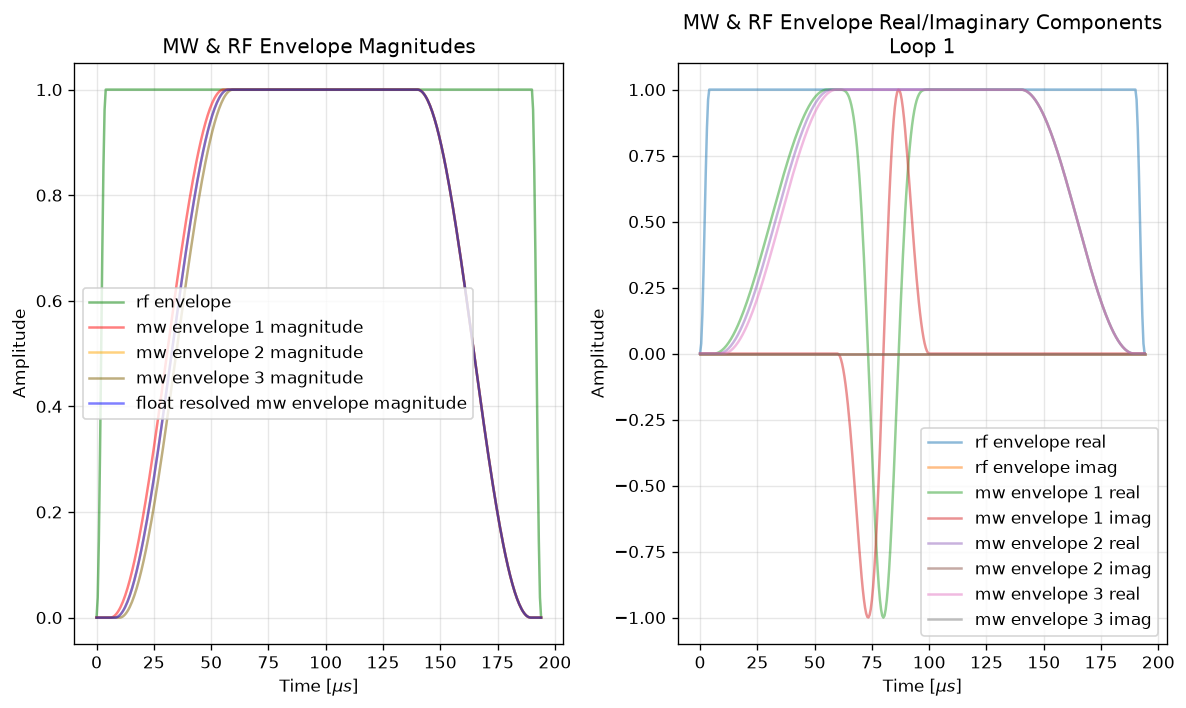

In [409]:
# All the envelopes should ramp between 0 and 1, all scalings are external

def sin2_envelope(time_us, T):
    return np.sin((np.pi * time_us) / (2 * T))**2

def rf_envelope(time_us):
    ramp_start_time_us = time_us - t_rf_ramp_start_us
    ramp_end_time_us = time_us - t_rf_ramp_down_start_us
    ramp_up = sin2_envelope(ramp_start_time_us, rf_loop_ramp_us)
    ramp_down = 1.0 - sin2_envelope(ramp_end_time_us, rf_loop_ramp_us)

    envelope = np.where(
        time_us < t_rf_on_us,
        ramp_up,
        np.where(
            time_us < t_rf_ramp_down_start_us,
            1.0,
            np.where(time_us < TOTAL_TIME_US, ramp_down, 0.0),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope

def mw_berry_loop_envelope(loop_time_us):
    phi_t_us = 2 * np.pi * sin2_envelope(loop_time_us, berry_loop_duration_us)
    return np.exp(-1j * phi_t_us)

def mw_loop_sequence_envelope(time_us, loop = "1", order="1"):
    """
    Inputs
    ------
        time_us : np.array
            The simulation time in microseconds
        loop : str
            Either "1", "2", or "const". Determines which loop (if either) the mw undergoes the phase change
        order : str
            Either "1", "2", or "3". Determines the order the mw is ramped on.
    
    Returns
    -------
        mw_envelope : np.array
            An envelope array corresponding to the input simulation time

    Notes
    -----
        Please use the SIMULATION_TIME global variable, the code will be sad if u dont :(
    """

    if order == "1":
        t_mw_ramp_start_us = t_mw1_ramp_start_us
        t_mw_ramp_end_us = t_mw_ramp_start_us + mw_loop_ramp_us
    elif order == "2":
        t_mw_ramp_start_us = t_mw2_ramp_start_us
        t_mw_ramp_end_us = t_mw_ramp_start_us + mw_loop_ramp_us
    elif order == "3":
        t_mw_ramp_start_us = t_mw3_ramp_start_us
        t_mw_ramp_end_us = t_mw_ramp_start_us + mw_loop_ramp_us
    else:
        raise ValueError("Variable 'order' must be either '1', '2', or '3'")
    
    # rf plateau, MW is all zeros
    plateau_time = time_us[time_us < t_mw_ramp_start_us]
    plateau = np.zeros_like(plateau_time)

    # make the time and the mw amplitude when ramping up
    ramp_up_time_bool = np.logical_and(time_us >= t_mw_ramp_start_us, time_us < t_mw_ramp_end_us)
    ramp_up_time = time_us[ramp_up_time_bool]
    zeroed_ramp_up_time = ramp_up_time - ramp_up_time[0]
    ramp_up = sin2_envelope(zeroed_ramp_up_time, np.max(zeroed_ramp_up_time))

    # check to see if there is time after full ramp and loop1, if so, repeat the values
    mw_on_pre_loop_time_bool = np.logical_and(time_us >= t_mw_ramp_end_us, time_us < t_loop_1_start_us)
    mw_on_pre_loop_time = time_us[mw_on_pre_loop_time_bool]
    mw_on_pre_loop = np.ones_like(mw_on_pre_loop_time) # this should return an empty array if there is no spacing

    # perform the first loop
    loop_1_time_bool = np.logical_and(time_us >= t_loop_1_start_us, time_us < t_loop_2_start_us)
    loop_1_time = time_us[loop_1_time_bool]
    zeroed_loop_1_time = loop_1_time - loop_1_time[0]
    loop_1 = mw_berry_loop_envelope(zeroed_loop_1_time)

    # immediately fire the second loop
    loop_2_time_bool = np.logical_and(time_us >= t_loop_2_start_us, time_us < t_mw_ramp_down_start_us)
    loop_2_time = time_us[loop_2_time_bool]
    zeroed_loop_2_time = loop_2_time - loop_2_time[0]
    loop_2 = np.ones_like(zeroed_loop_2_time)

    # keep constant if not state for loop
    loop_12_time = np.concatenate((loop_1_time, loop_2_time))
    const = np.ones_like(loop_12_time)

    # ramp the MWs down
    ramp_down_time_bool = np.logical_and(time_us >= t_mw_ramp_down_start_us, time_us < t_rf_ramp_down_start_us)
    ramp_down_time = time_us[ramp_down_time_bool]
    zeroed_ramp_down_time = ramp_down_time - ramp_down_time[0]
    ramp_down = (1 - sin2_envelope(zeroed_ramp_down_time, np.max(zeroed_ramp_down_time)))

    # keep the MWs 0 during RF ramp down
    rf_ramp_down_time_bool = np.logical_and( time_us >= t_rf_ramp_down_start_us, time_us <= TOTAL_TIME_US)
    rf_ramp_down_time = time_us[rf_ramp_down_time_bool]
    zeroed_rf_ramp_down_time = rf_ramp_down_time - rf_ramp_down_time[0]
    rf_ramp_down =  np.zeros_like(zeroed_rf_ramp_down_time)

    # to preserve the length append 0 at the end
    if loop == "1":
        mw_envelope = np.concatenate((plateau, ramp_up, mw_on_pre_loop, loop_1, loop_2, ramp_down, rf_ramp_down))
    elif loop == "2":
        mw_envelope = np.concatenate((plateau, ramp_up, mw_on_pre_loop, loop_2, loop_1, ramp_down, rf_ramp_down))
    elif loop =="const":
        mw_envelope = np.concatenate((plateau, ramp_up, mw_on_pre_loop, const, ramp_down, rf_ramp_down))
    else:
        raise ValueError("Loop must be '1' or '2' or 'const'")
    
    return mw_envelope

def is_iterable(var):
    try:
        iter(var)
        return True
    except:
        return False
    
# Precompute each envelope once so the solver does not rebuild the full arrays at every call.
mw_envelope_grids = {
    f"{loop}-{order}": mw_loop_sequence_envelope(SIMULATION_TIME, loop, order)
    for loop in ("1", "2", "const") for order in ("1", "2", "3")
}

# create a float resolvable time which uses the simulation time to interpolate a
#   float from the cached envelope
def mw_loop_sequence_envelope_float_resolvable(time_us, loop, order, **kwargs):
    if is_iterable(time_us):
        envelope = mw_loop_sequence_envelope(time_us, loop, order)
        return envelope
    else:
        envelope = mw_envelope_grids[f"{loop}-{order}"]
        return np.interp(time_us, SIMULATION_TIME, envelope)

rf_envelope_plot = rf_envelope(SIMULATION_TIME)
mw_envelope_1 = mw_loop_sequence_envelope(SIMULATION_TIME, loop="1", order="1")
mw_envelope_2 = mw_loop_sequence_envelope(SIMULATION_TIME, loop="const", order="2")
mw_envelope_3 = mw_loop_sequence_envelope(SIMULATION_TIME, loop="const", order="3")
mw_envelope_float_resolvable = mw_loop_sequence_envelope_float_resolvable(SIMULATION_TIME, loop="const", order="2")

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].plot(SIMULATION_TIME, rf_envelope_plot, 
                    alpha=0.5, color='green', label='rf envelope')
ax[0].plot(SIMULATION_TIME, np.abs(mw_envelope_1), 
                    alpha=0.5, color='red', label='mw envelope 1 magnitude')
ax[0].plot(SIMULATION_TIME, np.abs(mw_envelope_2), 
                    alpha=0.5, color='orange', label='mw envelope 2 magnitude')
ax[0].plot(SIMULATION_TIME, np.abs(mw_envelope_3), 
                    alpha=0.5, color='xkcd:shit', label='mw envelope 3 magnitude')
ax[0].plot(SIMULATION_TIME, np.abs(mw_envelope_float_resolvable), 
                    alpha=0.5, color='blue', label='float resolved mw envelope magnitude')
ax[0].set_title("MW & RF Envelope Magnitudes")
ax[0].set_ylabel("Amplitude")
ax[0].set_xlabel(r"Time $[\mu s]$")
ax[0].legend()

ax[1].plot(SIMULATION_TIME, rf_envelope_plot.real, label='rf envelope real', alpha=0.5,)# color="xkcd:shocking pink")
ax[1].plot(SIMULATION_TIME, rf_envelope_plot.imag, label='rf envelope imag', alpha=0.5,)# color="xkcd:purpley pink")
ax[1].plot(SIMULATION_TIME, mw_envelope_1.real, label='mw envelope 1 real', alpha=0.5,)# color="xkcd:red orange")
ax[1].plot(SIMULATION_TIME, mw_envelope_1.imag, label='mw envelope 1 imag', alpha=0.5,)# color="xkcd:fuchsia")
ax[1].plot(SIMULATION_TIME, mw_envelope_2.real, label='mw envelope 2 real', alpha=0.5,)# color="xkcd:hunter green")
ax[1].plot(SIMULATION_TIME, mw_envelope_2.imag, label='mw envelope 2 imag', alpha=0.5,)# color="xkcd:sage")
ax[1].plot(SIMULATION_TIME, mw_envelope_3.real, label='mw envelope 3 real', alpha=0.5,)# color="xkcd:aqua blue")
ax[1].plot(SIMULATION_TIME, mw_envelope_3.imag, label='mw envelope 3 imag', alpha=0.5,)# color="xkcd:blue violet")
ax[1].set_ylabel("Amplitude")
ax[1].set_xlabel(r"Time $[\mu s]$")
ax[1].set_title("MW & RF Envelope Real/Imaginary Components\nLoop 1")
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [410]:
# # create the phase loops

# def phase_loop_1(time_us, **kwargs):
#     phase = np.zeros_like(time_us)

#     loop_1_bool = np.logical_and(time_us >= t_loop_1_start_us, time_us <= t_loop_2_start_us)
#     loop_1_time = time_us[loop_1_bool]
#     zeroed_loop_1_time = loop_1_time - loop_1_time[0]
#     phase_loop = 2 * np.pi * sin2_envelope(zeroed_loop_1_time, np.max(zeroed_loop_1_time))

#     phase[loop_1_bool] = phase_loop
#     phase[time_us > t_loop_2_start_us] = 2 * np.pi

#     return phase

# def phase_loop_2(time_us, **kwargs):
#     phase = np.zeros_like(time_us)

#     loop_2_bool = np.logical_and(time_us >= t_loop_2_start_us, time_us <= t_mw_ramp_down_start_us)
#     loop_2_time = time_us[loop_2_bool]
#     zeroed_loop_2_time = loop_2_time - loop_2_time[0]
#     phase_loop = 2 * np.pi * sin2_envelope(zeroed_loop_2_time, np.max(zeroed_loop_2_time))

#     phase[loop_2_bool] = phase_loop
#     phase[time_us > t_mw_ramp_down_start_us] = 2 * np.pi

#     return phase

# # Precompute the two phase grids once for scalar solver calls.
# mw_phase_grids = {
#     "1": phase_loop_1(SIMULATION_TIME),
#     "2": phase_loop_2(SIMULATION_TIME),
# }

# def phase_loop_1_float_resolvable(time_us, **kwargs):
#     if is_iterable(time_us):
#         phase = phase_loop_1(time_us)
#         return phase
#     else:
#         return np.interp(time_us, SIMULATION_TIME, mw_phase_grids["1"])

# def phase_loop_2_float_resolvable(time_us, **kwargs):
#     if is_iterable(time_us):
#         phase = phase_loop_2(time_us)
#         return phase
#     else:
#         return np.interp(time_us, SIMULATION_TIME, mw_phase_grids["2"])
    
# loop_1_phase = phase_loop_1(SIMULATION_TIME)
# loop_2_phase = phase_loop_2(SIMULATION_TIME)

# plt.plot(SIMULATION_TIME, loop_1_phase, label=r'$\phi_1(t)$')
# plt.plot(SIMULATION_TIME, loop_2_phase, label=r'$\phi_2(t)$')

# plt.xlabel(f'Time $[\mu s]$')    
# plt.ylabel("Phase [rad]")
# plt.title("Phase Loop Functions")
# plt.legend()
# plt.show()

## Display all MW envelopes

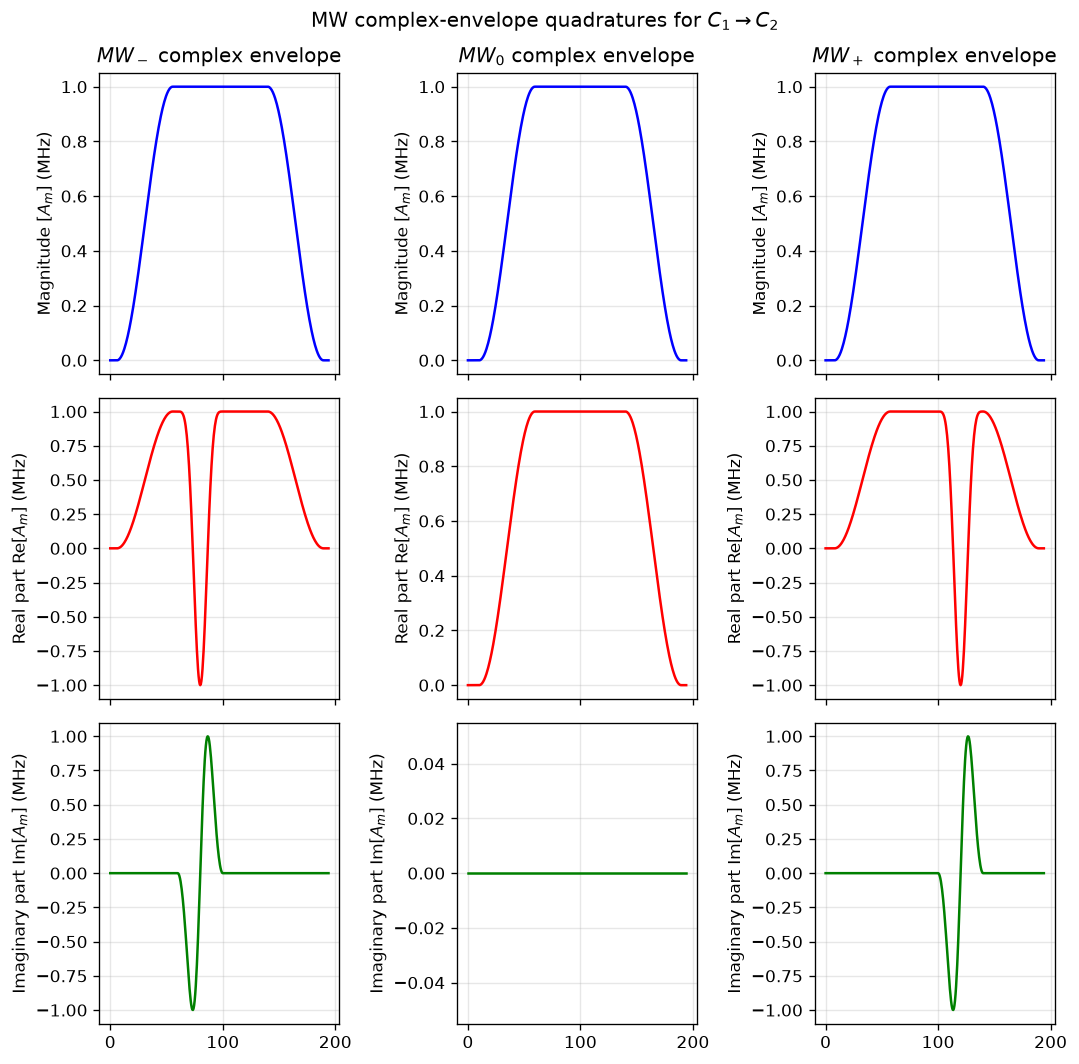

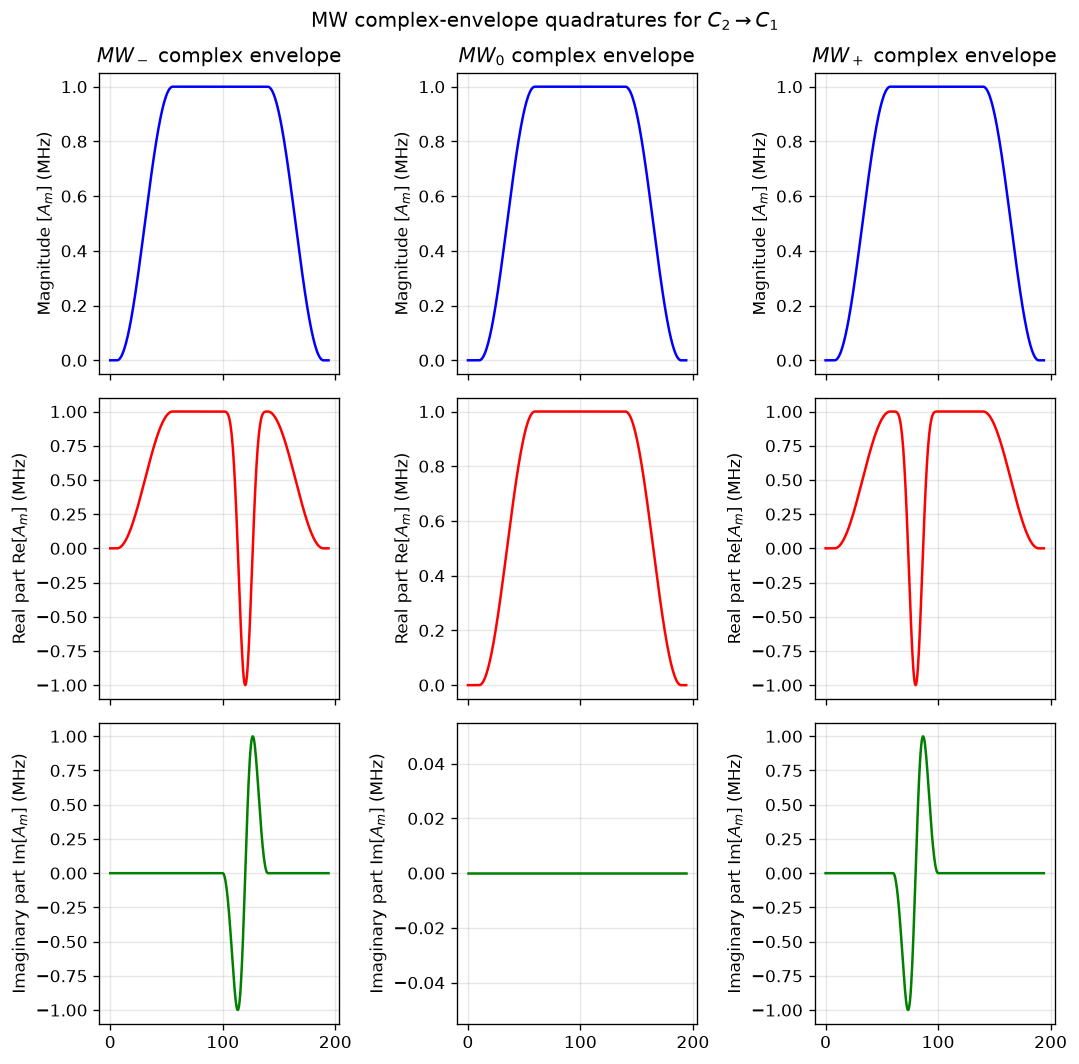

In [411]:
mw_gminus_c1c2_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="1", order="1")
mw_gminus_c2c1_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="2", order="1")
mw_gplus_c1c2_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="2", order="2")
mw_gplus_c2c1_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="1", order="2")
mw_gzero_c1c2_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="const", order="3")
mw_gzero_c2c1_plot = mw_loop_sequence_envelope(SIMULATION_TIME, loop="const", order="3")

mw_plots = [[mw_gminus_c1c2_plot, mw_gzero_c1c2_plot, mw_gplus_c1c2_plot], [mw_gminus_c2c1_plot, mw_gzero_c2c1_plot, mw_gplus_c2c1_plot]]
suptitles = [r"MW complex-envelope quadratures for $C_1 \rightarrow C_2$", r"MW complex-envelope quadratures for $C_2 \rightarrow C_1$"]
mw_titles = [r"$MW_-$ complex envelope", r"$MW_0$ complex envelope", r"$MW_+$ complex envelope"]

for mw_loop, suptitle in zip(mw_plots, suptitles):
    fig, ax = plt.subplots(3, 3, figsize=[9, 9], sharex=True)

    for mw_ind, mw, mw_title in zip(np.arange(len(mw_loop)), mw_loop, mw_titles):
        ax[0, mw_ind].plot(SIMULATION_TIME, np.abs(mw), color='blue')
        ax[0, mw_ind].set_ylabel(r"Magnitude $[A_m]$ (MHz)")

        ax[1, mw_ind].plot(SIMULATION_TIME, mw.real, color='red')
        ax[1, mw_ind].set_ylabel(r"Real part Re$[A_m]$ (MHz)")

        ax[2, mw_ind].plot(SIMULATION_TIME, mw.imag, color='green')
        ax[2, mw_ind].set_ylabel(r"Imaginary part Im$[A_m]$ (MHz)")

        ax[0, mw_ind].set_title(mw_title)

    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

## Define all carrier functions for pulses and Static Ham with RF

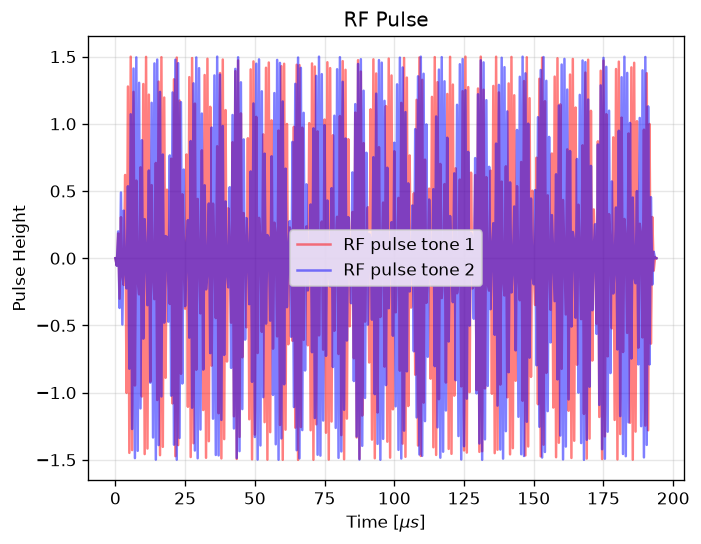

In [412]:
# for the pulses, use the envelope multiplied by a carrier cosine wave
#   A small note : the coefficients are the functions which define the shape of the pulse
#                   the pulses themselves are actually defined as the RF/MW hamiltonian * RF/MW coefficient

# Again, the coefficients should range between 0 and 1 and scale externally according to the Rabi frequency

# first, define the carrier frequencies
#   Note : we are using equal couplings for equal transition probabilities
rf_minus_zero_carrier_mhz = RF_CARRIER_FREQ_MHZ[0]
rf_zero_plus_carrier_mhz = RF_CARRIER_FREQ_MHZ[1]

# no rf phase
def rf_phase(t):
    return np.zeros_like(t)

# define a two-tone RF pulse to account for the transition frequencies between the excited states
def rf_lab_coefficient_tone_1(time_us, **kwargs):
    solver_time = time_us / (2. * np.pi)
    # tone_1 = np.cos(solver_time * RF_CARRIER_FREQ_MHZ + RF_PHASES[0]) # e- <-> e0 transition tone
    tone_1 = OMEGA_RF_MHZ * np.cos(time_us * rf_minus_zero_carrier_mhz + RF_PHASES[0]) # e- <-> e0 transition tone
    
    # phase = rf_phase(solver_time)
    # tone_1 = RF_CARRIER_FREQ_MHZ * np.exp(1j * phase)

    # get the rf envelope
    envelope = rf_envelope(solver_time)

    return envelope * tone_1

def rf_lab_coefficient_tone_2(time_us, **kwargs):
    solver_time = time_us / (2.0 * np.pi)
    # tone_2 = np.cos(solver_time * RF_CARRIER_FREQ_MHZ + RF_PHASES[1]) # e0 <-> e+ transition tone
    tone_2 = OMEGA_RF_MHZ * np.cos(time_us * rf_zero_plus_carrier_mhz + RF_PHASES[1]) # e0 <-> e+ transition tone

    # phase = rf_phase(solver_time)
    # tone_2 = RF_CARRIER_FREQ_MHZ * np.exp(1j * phase)
    
    envelope = rf_envelope(solver_time)

    return envelope * tone_2

test_sim_time = SIMULATION_TIME * np.pi * 2
plt.plot(SIMULATION_TIME, rf_lab_coefficient_tone_1(test_sim_time), alpha=0.5, color='red', label='RF pulse tone 1')
plt.plot(SIMULATION_TIME, rf_lab_coefficient_tone_2(test_sim_time), alpha=0.5, color='blue', label='RF pulse tone 2')
plt.legend()
plt.xlabel(r"Time $[\mu s]$")
plt.ylabel("Pulse Height")
plt.title("RF Pulse")
plt.show()

## Construct the static dressed ham in lab frame using RWA approximation

In [413]:
# project the RF hamiltonian into the bare excited basis
rf_projected_matrix = np.array([
    [complex(final_state.dag() * nv.RF_h1 * initial_state) for initial_state in bare_excited_states]
    for final_state in bare_excited_states
])
print(f'the rf matrix projected into the bare excited basis is\n{rf_projected_matrix}\n')

# we want the two matrix elements which tie e- <-> e0 and e0 <-> e+
d_minus_zero = rf_projected_matrix[1, 0] # <e0 | H_RF | e->
d_zero_plus = rf_projected_matrix[1, 2] # <e0 | H_RF | e+>
assert np.isclose(rf_projected_matrix[1, 0], rf_projected_matrix[0, 1].conj())
assert np.isclose(rf_projected_matrix[1, 2], rf_projected_matrix[2, 1].conj())

# apply rotating wave approximation
#   Note : check the latex after this cell
g_minus_zero = ((OMEGA_RF_MHZ / 2) * 
                    d_minus_zero *
                    np.exp(-1j * RF_PHASES[0])
)
g_zero_plus = ((OMEGA_RF_MHZ / 2) * 
                    d_zero_plus *
                    np.exp(-1j * RF_PHASES[1])
)

# assemble the dressed ham with detunings included
H_dressed_mhz = np.diag(DETUNINGS_MHZ).astype(np.complex128)
H_dressed_mhz[1, 0] = g_minus_zero
H_dressed_mhz[0, 1] = g_minus_zero.conj()
H_dressed_mhz[1, 2] = g_zero_plus
H_dressed_mhz[2, 1] = g_zero_plus.conj()
print(f'the dressed static hamiltonian from RWA with RF and detunings included is\n{H_dressed_mhz}\n')

# diagonalize the dressed hamiltonian
dressed_quasienergies_mhz, dressed_eigenstates = np.linalg.eigh(H_dressed_mhz)
print("Dressed quasienergies:")
print(dressed_quasienergies_mhz)
print("Dressed coefficient vectors:")
print(dressed_eigenstates)
print()

the rf matrix projected into the bare excited basis is
[[0.        +0.j 0.99999932+0.j 0.        +0.j]
 [0.99999932+0.j 0.        +0.j 1.        +0.j]
 [0.        +0.j 1.        +0.j 0.        +0.j]]

the dressed static hamiltonian from RWA with RF and detunings included is
[[0.        +0.j 0.74999949-0.j 0.        +0.j]
 [0.74999949+0.j 0.        +0.j 0.75      +0.j]
 [0.        +0.j 0.75      -0.j 0.        +0.j]]

Dressed quasienergies:
[-1.06065981e+00  8.85606963e-17  1.06065981e+00]
Dressed coefficient vectors:
[[ 4.99999830e-01+0.j -7.07107022e-01+0.j  4.99999830e-01+0.j]
 [-7.07106781e-01+0.j -2.15105711e-16+0.j  7.07106781e-01+0.j]
 [ 5.00000170e-01+0.j  7.07106541e-01+0.j  5.00000170e-01+0.j]]



RWA math:

We want to look at the transition terms 

$\ket{x_-} \leftrightarrow \ket{x_0} \text{and} \ket{x_0} \leftrightarrow \ket{x_+}$

We will build the active Hamiltonian of the form

$H_{0, active} = \Sigma_{(-, 0, +)} E_{g_i} \ket{g_i}\bra{g_i} + \Sigma_{(-, 0, +)} E_{x_i} \ket{x_i}\bra{x_i}$

And a rotation operator of the form

$U_0 = \exp{[-i 2 \pi H_{0, active} t]}$

Then, rotate transition elements of the RF hamiltonian, for example $\ket{x_0}\bra{x_-}$

$U_0^\dag \ket{x_0}\bra{x_-} U_0 = \exp{[-i 2 \pi (E_{x_0} - E_{x_-}) t]} \ket{x_0}\bra{x_-}$

Define $f_{-0} = E_{x_0} - E_{x_-}$

Then expand the exponential into a cosine term

$\cos{2 \pi f_{-0} t + \phi_{-0}} = \frac{1}{2} [\exp{[i 2 \pi f_{-0} t + \phi_{-0}]} + \exp{[-i 2 \pi f_{-0} t + \phi_{-0}]}]$

$\exp{[i 2 \pi f_{-0} t]} \cos{2 \pi f_{-0} t + \phi_{-0}} = \frac{1}{2} [\exp{[i 4 \pi f_{-0} t + \phi_{-0}]} + \exp{[-i\phi_{-0}]}]$

We may discard the rapidly oscillating term at $2f_{-0}$ by RWA.
Then, we can use 

$H_{\text{RF}}^{\text{lab}}(t) = \Omega_{\text{RF}} f_{\text{RF}}(t) \cos{(2 \pi f_{\text{carrier}} t + \phi_{\text{carrier}})} H_{\text{RF}}$

and make our substitution to find

$H_{\text{RF}}^{\text{RWA}}(t) = \frac{\Omega_{\text{RF}} f_{\text{RF}}(t)}{2}[d_{-0} \exp{(i 2 \pi f_{-0} t - \phi_{\text{carrier}})}] H_{\text{RF}, -0} + \text{h.c}$

Where $d_{-0}$ is an element inthe lab frame RF Hamiltonian.
Then, the elements in our RWA RF Hamiltonian are

$g_{0-} = \frac{\Omega_{RF}}{2} d_{0-}\exp{[-i\phi_{-0}]}$

and

$g_{0+} = \frac{\Omega_{RF}}{2} d_{0+}\exp{[-i\phi_{0+}]}$



## find the ancilla state in the NV basis

In [414]:
# take the lowest dressed eigenstate as the ancilla state and transform each dressed excited state
#  back into the original 9D basis. Make sure that the largest coefficient of the ancilla state is positive by 
#   by applying a global phase
dressed_excited_states = []
for dressed_coefficients in dressed_eigenstates.T:
    dressed_state = 0 * bare_excited_states[0]
    for coefficient, bare_state in zip(dressed_coefficients, bare_excited_states):
        dressed_state += coefficient * bare_state
    dressed_excited_states.append(dressed_state.unit())

ancilla_state, dressed_e_zero, dressed_e_plus = dressed_excited_states
ancilla_bare_coefficients = np.array([
    complex(state.dag() * ancilla_state) for state in bare_excited_states
])
max_ancilla_coeff_ind = np.argmax(np.abs(ancilla_bare_coefficients))
global_phase = np.exp(-1j * np.angle(ancilla_bare_coefficients[max_ancilla_coeff_ind]))
ancilla_state = global_phase * ancilla_state
dressed_excited_states[0] = ancilla_state
print(f'the ancilla state is\n{ancilla_state}')

# get the ancilla quasienergy
ancilla_quasienergy_mhz = dressed_quasienergies_mhz[0]
print(f'the ancilla quasienergy is : {ancilla_quasienergy_mhz} [MHz]\n')

# test the projection operators between the bare and dressed excited states
bare_projectors = [ket2dm(state) for state in bare_excited_states]

dressed_projectors = [ket2dm(state) for state in dressed_excited_states]
assert (
    np.sum(dressed_projectors) - np.sum(bare_projectors)
).norm() < 1e-12

# test orthonormality of the states
print(f'<e|e> = {ancilla_state.dag() * ancilla_state}')
print(f'<e0|e0> = {dressed_e_zero.dag() * dressed_e_zero}')
print(f'<e+|e+> = {dressed_e_plus.dag() * dressed_e_plus}')
print(f'<e|e+> = {ancilla_state.dag() * dressed_e_plus}')
print(f'<e+|e0> = {dressed_e_plus.dag() * dressed_e_zero}')
print(f'<e|e0> = {ancilla_state.dag() * dressed_e_zero}')


the ancilla state is
Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 1.40954101e-06]
 [ 0.00000000e+00]
 [ 5.85282134e-04]
 [-8.24897872e-04]
 [-4.99999828e-01]
 [ 7.07106300e-01]
 [-4.99999830e-01]]
the ancilla quasienergy is : -1.060659810906894 [MHz]

<e|e> = (1+0j)
<e0|e0> = (1+0j)
<e+|e+> = (1.0000000000000002+0j)
<e|e+> = (8.326672684688674e-17-6.162975822039155e-33j)
<e+|e0> = (5.551115123125783e-17+0j)
<e|e0> = (-2.7755575615628914e-16+3.0814879110195774e-32j)


## put the MW transition frequencies in tune with the new ancilla state

Currently we have the transitions of each ground state to its corresponding undressed excited states via a $\Delta m_s = \pm 1$ transition.
However, because we have now dressed the excited states, our energies have shifted and therefore we msut correct the MW pulse frequencies.

In [415]:
# The RF-dressed carrier for each leg is its bare transition frequency plus
# the selected ancilla quasienergy. These frequencies define the frame and
# therefore do not appear as GHz cosines in the rotating-frame solver.
MW_DRESSED_CARRIER_FREQ_MHZ = OMEGA_MW_MHZ + ancilla_quasienergy_mhz

labels = ["MW-", "MW0", "MW+"]
print(f'the shifted MW frequencies to the dressed ancilla state are\n')
for lab, freq, freq_bare in zip(labels, MW_DRESSED_CARRIER_FREQ_MHZ, OMEGA_MW_MHZ):
    print(f'{lab} dressed carrier frequency: {freq} [MHz]')
    print(f'{lab} bare carrier frequency: {freq_bare} [MHz]\n')


def mw_minus_pulse_C1C2(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="1", order="1")
    return np.exp(-1j * MW_PHASES[0]) * envelope

def mw_zero_pulse_C1C2(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="const", order="2")
    return np.exp(-1j * MW_PHASES[1]) * envelope

def mw_plus_pulse_C1C2(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="2", order="3")
    return np.exp(-1j * MW_PHASES[2]) * envelope

def mw_minus_pulse_C2C1(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="2", order="1")
    return np.exp(-1j * MW_PHASES[0]) * envelope

def mw_zero_pulse_C2C1(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="const", order="2")
    return np.exp(-1j * MW_PHASES[1]) * envelope

def mw_plus_pulse_C2C1(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="1", order="3")
    return np.exp(-1j * MW_PHASES[2]) * envelope

def mw_minus_pulse_no_loops(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="const", order="1")
    return np.exp(-1j * MW_PHASES[0]) * envelope

def mw_zero_pulse_no_loops(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="const", order="2")
    return np.exp(-1j * MW_PHASES[1]) * envelope

def mw_plus_pulse_no_loops(t, **kwargs):
    solver_time = t / (2 * np.pi)
    envelope = mw_loop_sequence_envelope_float_resolvable(solver_time, loop="const", order="3")
    return np.exp(-1j * MW_PHASES[2]) * envelope

the shifted MW frequencies to the dressed ancilla state are

MW- dressed carrier frequency: 2306.3034622399837 [MHz]
MW- bare carrier frequency: 2307.3641220508907 [MHz]

MW0 dressed carrier frequency: 2308.4487495637222 [MHz]
MW0 bare carrier frequency: 2309.5094093746293 [MHz]

MW+ dressed carrier frequency: 2310.585594908677 [MHz]
MW+ bare carrier frequency: 2311.6462547195842 [MHz]



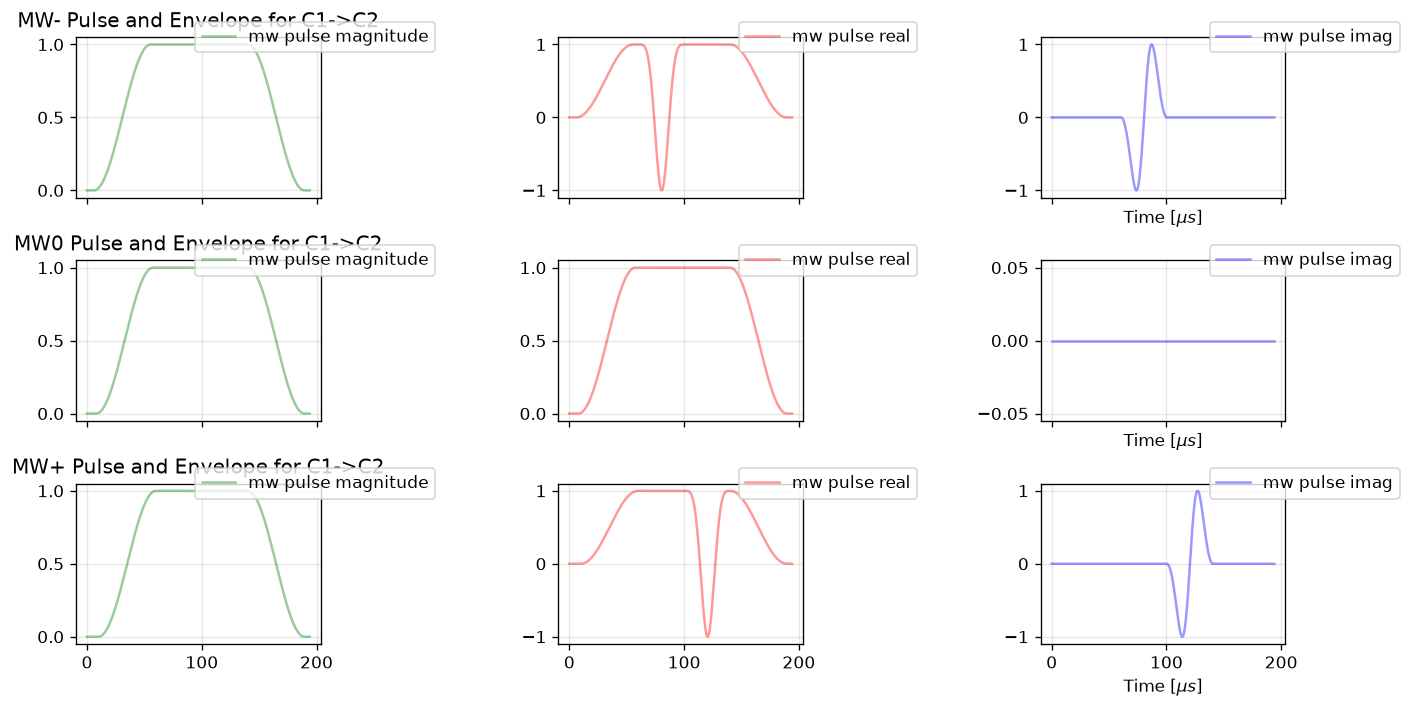

In [416]:
# Example plot for MW Pulses in the C1->C2 loop
mw_minus_pulse = mw_minus_pulse_C1C2(SIMULATION_TIME * 2 * np.pi)
mw_zero_pulse = mw_zero_pulse_C1C2(SIMULATION_TIME * 2 * np.pi)
mw_plus_pulse = mw_plus_pulse_C1C2(SIMULATION_TIME * 2 * np.pi)

fig, axes = plt.subplots(3, 3, figsize=(12, 6), sharex=True)

axes[0, 0].plot(SIMULATION_TIME, np.abs(mw_minus_pulse), alpha=0.4, color='green', label='mw pulse magnitude')
axes[1, 0].plot(SIMULATION_TIME, np.abs(mw_zero_pulse), alpha=0.4, color='green', label='mw pulse magnitude')
axes[2, 0].plot(SIMULATION_TIME, np.abs(mw_plus_pulse), alpha=0.4, color='green', label='mw pulse magnitude')

axes[0, 1].plot(SIMULATION_TIME, mw_minus_pulse.real, alpha=0.4, color='red', label='mw pulse real')
axes[1, 1].plot(SIMULATION_TIME, mw_zero_pulse.real, alpha=0.4, color='red', label='mw pulse real')
axes[2, 1].plot(SIMULATION_TIME, mw_plus_pulse.real, alpha=0.4, color='red', label='mw pulse real')

axes[0, 2].plot(SIMULATION_TIME, mw_minus_pulse.imag, alpha=0.4, color='blue', label='mw pulse imag')
axes[1, 2].plot(SIMULATION_TIME, mw_zero_pulse.imag, alpha=0.4, color='blue', label='mw pulse imag')
axes[2, 2].plot(SIMULATION_TIME, mw_plus_pulse.imag, alpha=0.4, color='blue', label='mw pulse imag')

axes[0, 0].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[0, 1].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[0, 2].legend(loc='right', bbox_to_anchor=(1.5, 1))

axes[1, 0].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[1, 1].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[1, 2].legend(loc='right', bbox_to_anchor=(1.5, 1))

axes[2, 0].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[2, 1].legend(loc='right', bbox_to_anchor=(1.5, 1))
axes[2, 2].legend(loc='right', bbox_to_anchor=(1.5, 1))

# max_of_mw = np.max(np.abs(mw_minus_pulse))
# for ax in axes.flat:
#     ax.vlines(0, -max_of_mw, max_of_mw, linestyles='--', label='mw_loop_ramp_us', colors='purple')
#     ax.vlines(mw_loop_ramp_us, -max_of_mw, max_of_mw, linestyles='--', label='mw_loop_ramp_us', colors='green')
#     ax.vlines(t_loop_1_start_us, -max_of_mw, max_of_mw, linestyles='--', label='t_loop_1_start_us', colors='red')
#     ax.vlines(t_loop_2_start_us, -max_of_mw, max_of_mw, linestyles='--', label='t_loop_2_start_us', colors='orange')
#     ax.vlines(t_mw_ramp_down_start_us, -max_of_mw, max_of_mw, linestyles='--', label='t_mw_ramp_down_start_us', colors='green')
#     ax.vlines(t_rf_ramp_down_start_us, -max_of_mw, max_of_mw, linestyles='--', label='t_rf_ramp_down_start_us', colors='purple')
#     ax.vlines(TOTAL_TIME_US, -max_of_mw, max_of_mw, linestyles='--', label='loop_sequence_duration_us')
#     # if ax == axes[-1]:
#     #     ax.legend(loc='right', bbox_to_anchor=(1.5, 1))
    
#     ax.set_ylabel('Amplitude')

axes[0, 2].set_xlabel(r'Time $[\mu s]$')
axes[1, 2].set_xlabel(r'Time $[\mu s]$')
axes[2, 2].set_xlabel(r'Time $[\mu s]$')

axes[0, 0].set_title("MW- Pulse and Envelope for C1->C2")
axes[1, 0].set_title("MW0 Pulse and Envelope for C1->C2")
axes[2, 0].set_title("MW+ Pulse and Envelope for C1->C2")

plt.tight_layout()
plt.show()

## construct the observable projection operators

In [417]:
P_g_minus = ket2dm(g_minus)
P_g_zero = ket2dm(g_zero)
P_g_plus = ket2dm(g_plus)

P_ancilla = ket2dm(ancilla_state)
P_e_zero = ket2dm(dressed_excited_states[1])
P_e_plus = ket2dm(dressed_excited_states[2])

P_x_minus = ket2dm(bare_e_minus)
P_x_zero = ket2dm(bare_e_zero)
P_x_plus = ket2dm(bare_e_plus)

P_s_minus = ket2dm(s_minus)
P_s_zero = ket2dm(s_zero)
P_s_plus = ket2dm(s_plus)

P_tripod_states = P_g_minus + P_g_zero + P_g_plus + P_ancilla # the population of all tripod states
P_all_ground_and_excited_states = P_tripod_states + P_e_zero + P_e_plus
P_all_states = P_all_ground_and_excited_states + P_s_minus + P_s_zero + P_s_plus

list_of_bare_projection_operators = [P_g_minus, P_g_zero, P_g_plus,
                                     P_x_minus, P_x_zero, P_x_plus,
                                     P_s_minus, P_s_zero, P_s_plus,]

## DEFINE THE INITIAL STATE HERE

In [418]:
INITIAL_STATE = (g_minus - g_zero) / np.sqrt(2)

# ensure normalization
print(f"<psi | psi> = {INITIAL_STATE.dag() * INITIAL_STATE}")

<psi | psi> = (0.9999999999999998+0j)


## Do the pulsed sim experiments in the loops

In [419]:
# define the population observable operators and label appropriately
loop_population_observables = [
    P_g_minus,
    P_g_zero,
    P_g_plus,
    P_ancilla,
    P_tripod_states,
    P_all_ground_and_excited_states,
    P_all_states,
]
loop_population_labels = (
    r"$P_{g_-}$",
    r"$P_{g_0}$",
    r"$P_{g_+}$",
    r"$P_{\text{ancilla}}$",
    r"$P_{\text{tripod}}$",
    r"$P_{G+E}$",
    r"$P_{\rm all}$",
)


In [420]:
solver_total_simulation_time = SIMULATION_TIME * (2 * np.pi)

# Embed the RF RWA Hamiltonian in the original 9D NV Hilbert space.
P_active_excited = sum(ket2dm(state) for state in bare_excited_states)

# This is the detuning matrix, should be only diagonal elements
H_rf_detuning_mhz = sum(
    detuning * ket2dm(state)
    for detuning, state in zip(DETUNINGS_MHZ, bare_excited_states)
)

# This is the dressed hamiltonian in the 9D space
H_rf_coupling_mhz = (
    g_minus_zero * bare_e_zero * bare_e_minus.dag()
    + np.conj(g_minus_zero) * bare_e_minus * bare_e_zero.dag()
    + g_zero_plus * bare_e_zero * bare_e_plus.dag()
    + np.conj(g_zero_plus) * bare_e_plus * bare_e_zero.dag()
)

# Shift the excited manifold by the ancilla quasienergy. On the RF plateau,
# the selected ancilla and all three ground states then have zero energy.
H_loop_static_mhz = (
    H_rf_detuning_mhz
    - ancilla_quasienergy_mhz * P_active_excited
)

def rf_rotating_envelope(t, **kwargs):
    return rf_envelope(t / (2 * np.pi))

# Calibrate the physical MW amplitudes so every projected ancilla coupling
# has magnitude TARGET_MW_LEG_MHZ after the factor of 1/2 from the RWA.
eta = np.array([
    complex(ancilla_state.dag() * nv.MW_h1 * ground_state)
    for ground_state in ground_states
])
if np.any(np.abs(eta) < 1e-12):
    raise ValueError("A selected MW leg has a vanishing ancilla matrix element.")

MW_DRIVE_AMPLITUDES_MHZ = 2 * TARGET_MW_LEG_MHZ / np.abs(eta)
mw_bare_matrix_elements = np.array([
    complex(excited_state.dag() * nv.MW_h1 * ground_state)
    for excited_state, ground_state in zip(bare_excited_states, ground_states)
])
mw_phase_calibration = np.exp(-1j * np.angle(eta))
mw_forward_operators = [
    (
        0.5 * amplitude * phase_correction * matrix_element
        * excited_state * ground_state.dag()
    )
    for amplitude, phase_correction, matrix_element, excited_state, ground_state in zip(
        MW_DRIVE_AMPLITUDES_MHZ,
        mw_phase_calibration,
        mw_bare_matrix_elements,
        bare_excited_states,
        ground_states,
    )
]

mw_rotating_pulses = {
    "C1C2": [mw_minus_pulse_C1C2, mw_zero_pulse_C1C2, mw_plus_pulse_C1C2],
    "C2C1": [mw_minus_pulse_C2C1, mw_zero_pulse_C2C1, mw_plus_pulse_C2C1],
    "no_loops" : [mw_minus_pulse_no_loops, mw_zero_pulse_no_loops, mw_plus_pulse_no_loops],
}

def conjugate_coefficient(coefficient):
    def conjugated(t, **kwargs):
        return np.conj(coefficient(t, **kwargs))
    return conjugated


def build_pulsedsim_controls(loop_order="C1C2"):
    if loop_order not in mw_rotating_pulses:
        raise ValueError("loop_order must be 'C1C2' or 'C2C1'.")

    control_hamiltonians_pulsedsim = [H_rf_coupling_mhz]
    pulse_shapes_pulsedsim = [rf_rotating_envelope]

    for forward_operator, pulse in zip(
        mw_forward_operators, mw_rotating_pulses[loop_order]
    ):
        control_hamiltonians_pulsedsim.extend([
            forward_operator, forward_operator.dag()
        ])
        pulse_shapes_pulsedsim.extend([
            pulse, conjugate_coefficient(pulse)
        ])

    return control_hamiltonians_pulsedsim, pulse_shapes_pulsedsim


def run_rotating_experiment_pulsedsim(loop_order="C1C2"):
    system_pulsedsim = QSys(
        H0=H_loop_static_mhz,
        rho0=INITIAL_STATE,
        observable=loop_population_observables,
        units_H0="MHz",
    )
    experiment_pulsedsim = PulsedSim(system=system_pulsedsim)

    h1_pulsedsim, pulse_shapes_pulsedsim = build_pulsedsim_controls(
        loop_order
    )
    solver_options_pulsedsim = {
        "method": "vern9",
        "nsteps": 20_000,
        "atol": 1e-9,
        "rtol": 1e-7,
    }

    # add_pulse stores only the final state. Evolve one output interval at
    # a time so that the endpoint of every interval forms a trajectory.
    state_trajectory_pulsedsim = [INITIAL_STATE.copy()]
    for start_time_us, end_time_us in zip(
        SIMULATION_TIME[:-1], SIMULATION_TIME[1:]
    ):
        experiment_pulsedsim.add_pulse(
            duration=float(end_time_us - start_time_us),
            h1=h1_pulsedsim,
            pulse_shape=pulse_shapes_pulsedsim,
            time_steps=2,
            options=solver_options_pulsedsim,
        )
        state_trajectory_pulsedsim.append(
            experiment_pulsedsim.rho.copy()
        )

    experiment_pulsedsim.final_state = state_trajectory_pulsedsim[-1]
    experiment_pulsedsim.rho = state_trajectory_pulsedsim
    experiment_pulsedsim.variable = SIMULATION_TIME.copy()
    experiment_pulsedsim._get_results()
    return experiment_pulsedsim


In [421]:
def make_population_plots(
        experiment : PulsedSim, 
        loop : str, 
        axes : tuple[plt.Axes]
        ):
    g_minus_populations = experiment.results[0]
    g_zero_populations = experiment.results[1]
    g_plus_populations = experiment.results[2]
    ancilla_populations = experiment.results[3]
    tripod_states_populations = experiment.results[4]
    all_ground_and_excited_states_populations = experiment.results[5]
    all_states_populations = experiment.results[6]

    # fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    axes[0].plot(SIMULATION_TIME, g_minus_populations, label=loop_population_labels[0], 
                    color='#1f77b4', alpha=0.8, linestyle='-')
    axes[0].plot(SIMULATION_TIME, g_zero_populations, label=loop_population_labels[1], 
                    color='#17becf', alpha=0.8, linestyle='-')
    axes[0].plot(SIMULATION_TIME, g_plus_populations, label=loop_population_labels[2], 
                    color='#2a9d8f', alpha=0.8, linestyle='-')
    axes[0].plot(SIMULATION_TIME, ancilla_populations, label=loop_population_labels[3], 
                    color='#6a4c93', alpha=0.8, linestyle='-')
    axes[0].set_xlabel(r"Time $[\mu s]$")
    axes[0].set_ylabel("Population")
    axes[0].set_title(f"Individual Tripod Populations for loop {loop}")
    axes[0].legend(bbox_to_anchor=(1.05, 1))

    all_ground_pops = g_minus_populations + g_zero_populations + g_plus_populations
    all_excited_pops = all_ground_and_excited_states_populations - all_ground_pops
    axes[1].plot(SIMULATION_TIME, all_ground_and_excited_states_populations, label=loop_population_labels[5], 
                    color='#457b9d', alpha=0.8, linestyle='-')
    axes[1].plot(SIMULATION_TIME, all_states_populations - all_ground_and_excited_states_populations, label=r"$P_{S}$", 
                    color='#00b4d8', alpha=0.8, linestyle='-')
    axes[1].plot(SIMULATION_TIME, all_excited_pops, label=r"$P_{E}$", 
                    color='#5e60ce', alpha=0.8, linestyle='-')
    axes[1].plot(SIMULATION_TIME, all_ground_pops, label=r"$P_{G}$", 
                    color='#2a9d8f', alpha=0.8, linestyle='-')
    axes[1].plot(SIMULATION_TIME, all_states_populations, label=loop_population_labels[6], 
                    color='#3a0ca3', alpha=0.8, linestyle='-')
    axes[1].set_xlabel(r"Time $[\mu s]$")
    axes[1].set_ylabel("Population")
    axes[1].set_title("Full Ground, Excited, and Plus State Populations")

    for ax in axes:
        ax.vlines(0, 0, 1, linestyles='--', label='rf_loop_ramp_us', colors='#E76F51')
        ax.vlines(mw_loop_ramp_us, 0, 1, linestyles='--', label='mw_loop_ramp_us', colors='#F4A261')
        ax.vlines(t_loop_1_start_us, 0, 1, linestyles='--', label='t_loop_1_start_us', colors='#D62828')
        ax.vlines(t_loop_2_start_us, 0, 1, linestyles='--', label='t_loop_2_start_us', colors='#F77F00')
        ax.vlines(t_mw_ramp_down_start_us, 0, 1, linestyles='--', label='t_mw_ramp_down_start_us', colors='#F4A261')
        ax.vlines(t_rf_ramp_down_start_us, 0, 1, linestyles='--', label='t_rf_ramp_down_start_us', colors='#E76F51')
        ax.vlines(TOTAL_TIME_US, 0, 1, linestyles='--', label='loop_sequence_duration_us', colors='black')

    axes[1].legend(bbox_to_anchor=(1.65, 1))
    # plt.tight_layout()
    # plt.show()


In [422]:
experiment_C1C2_pulsedsim = run_rotating_experiment_pulsedsim("C1C2")
experiment_C2C1_pulsedsim = run_rotating_experiment_pulsedsim("C2C1")
experiment_no_loops_pulsedsim = run_rotating_experiment_pulsedsim("no_loops")

print("PulsedSim rotating-frame simulations complete.")
print(
    "C1C2 maximum total-population error:",
    np.max(np.abs(experiment_C1C2_pulsedsim.results[6] - 1.0)),
)
print(
    "C2C1 maximum total-population error:",
    np.max(np.abs(experiment_C2C1_pulsedsim.results[6] - 1.0)),
)
print(
    "No Loop maximum total-population error:",
    np.max(np.abs(experiment_no_loops_pulsedsim.results[6] - 1.0)),
)


PulsedSim rotating-frame simulations complete.
C1C2 maximum total-population error: 6.661338147750939e-16
C2C1 maximum total-population error: 6.661338147750939e-16
No Loop maximum total-population error: 6.661338147750939e-16


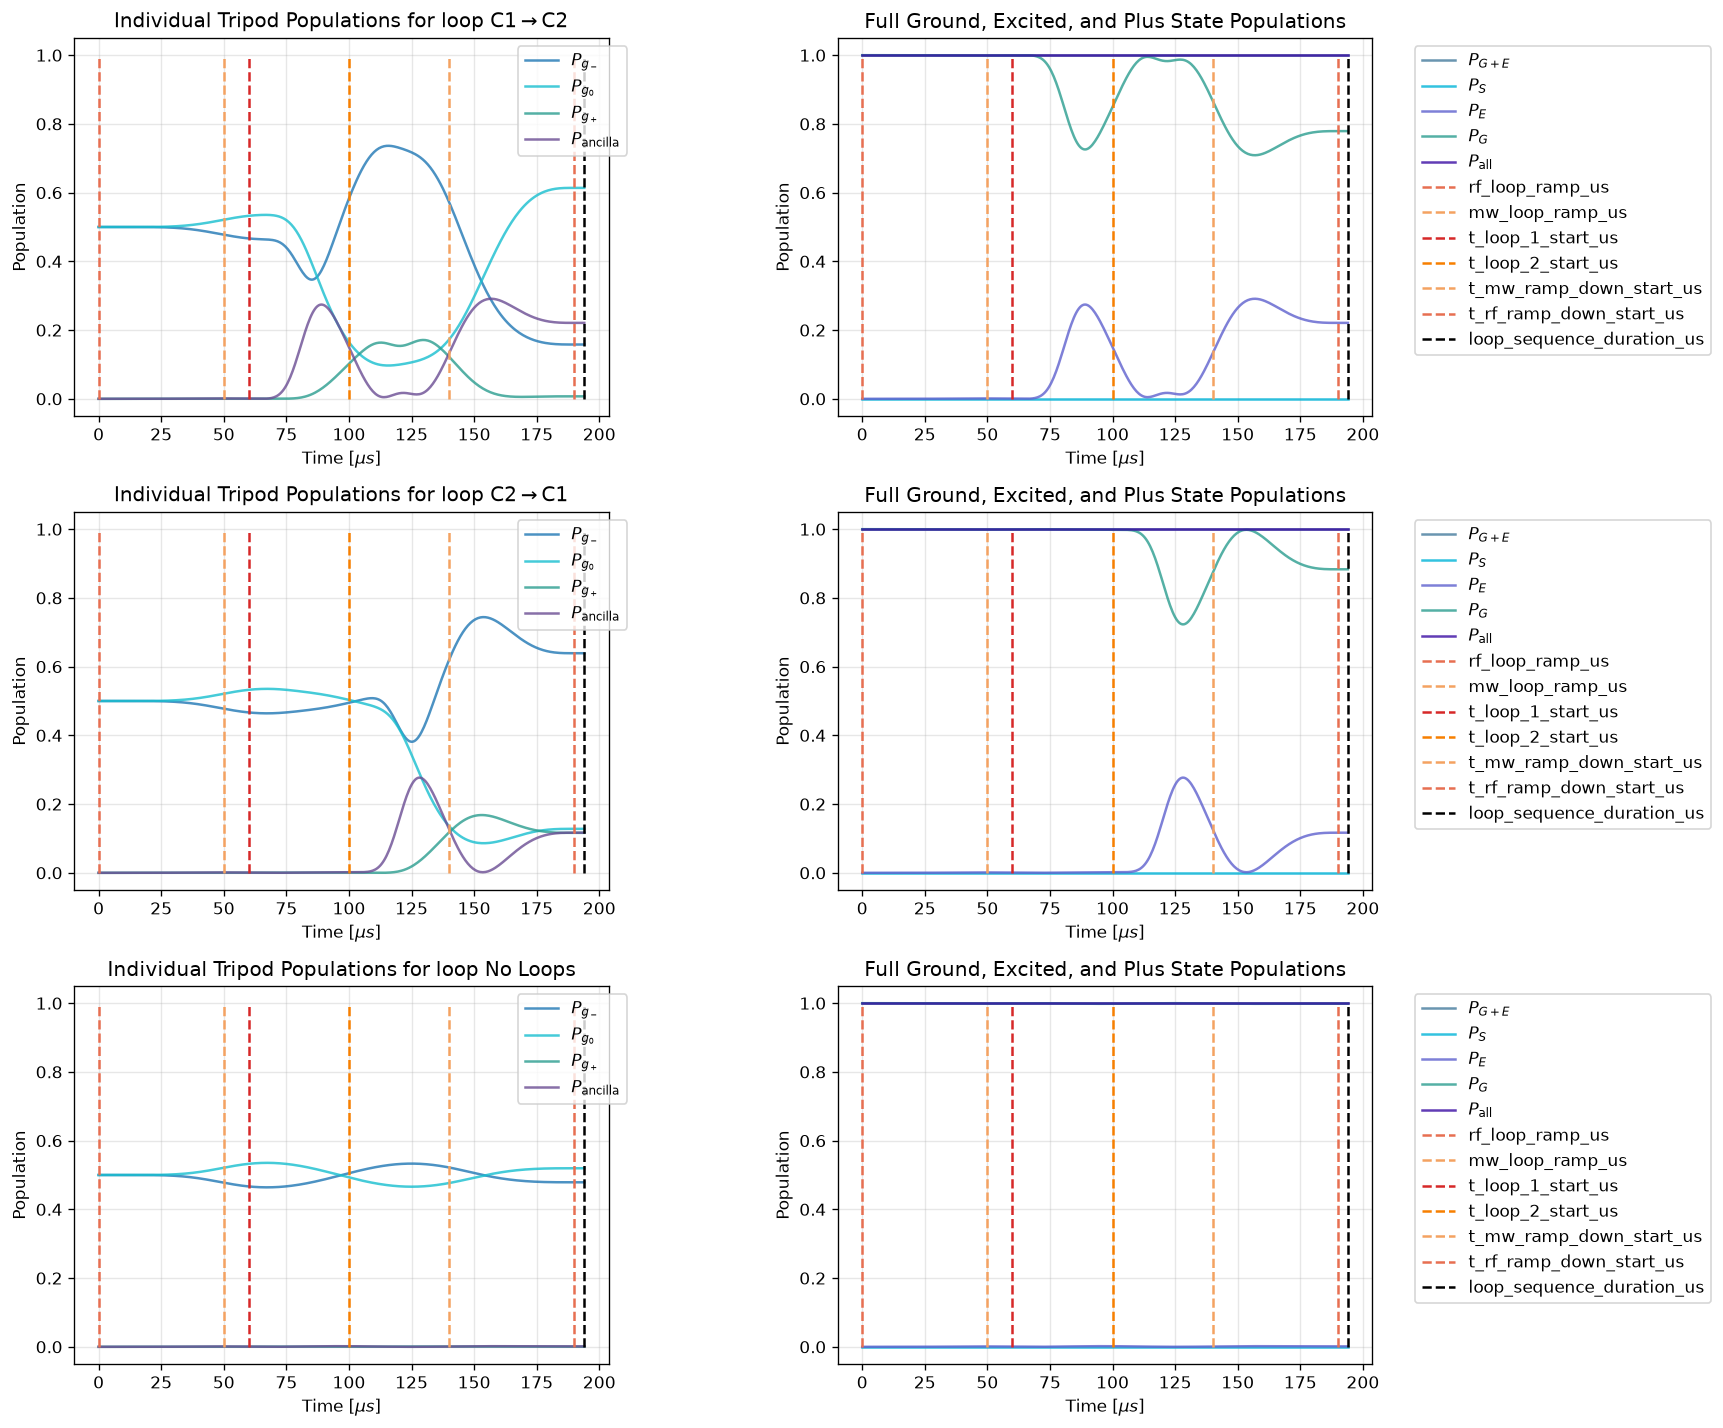

In [423]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

make_population_plots(experiment_C1C2_pulsedsim, loop=r'C1$\rightarrow$C2', axes=(axes[0, 0], axes[0, 1]))
make_population_plots(experiment_C2C1_pulsedsim, loop=r'C2$\rightarrow$C1', axes=(axes[1, 0], axes[1, 1]))
make_population_plots(experiment_no_loops_pulsedsim, loop=r'No Loops', axes=(axes[2, 0], axes[2, 1]))
plt.tight_layout()
plt.show()

/var/folders/p0/gr8qkmvx4sj_pcy59_665_mh0000gp/T/ipykernel_67246/2511331515.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_phi.show()
/var/folders/p0/gr8qkmvx4sj_pcy59_665_mh0000gp/T/ipykernel_67246/2511331515.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_r.show()


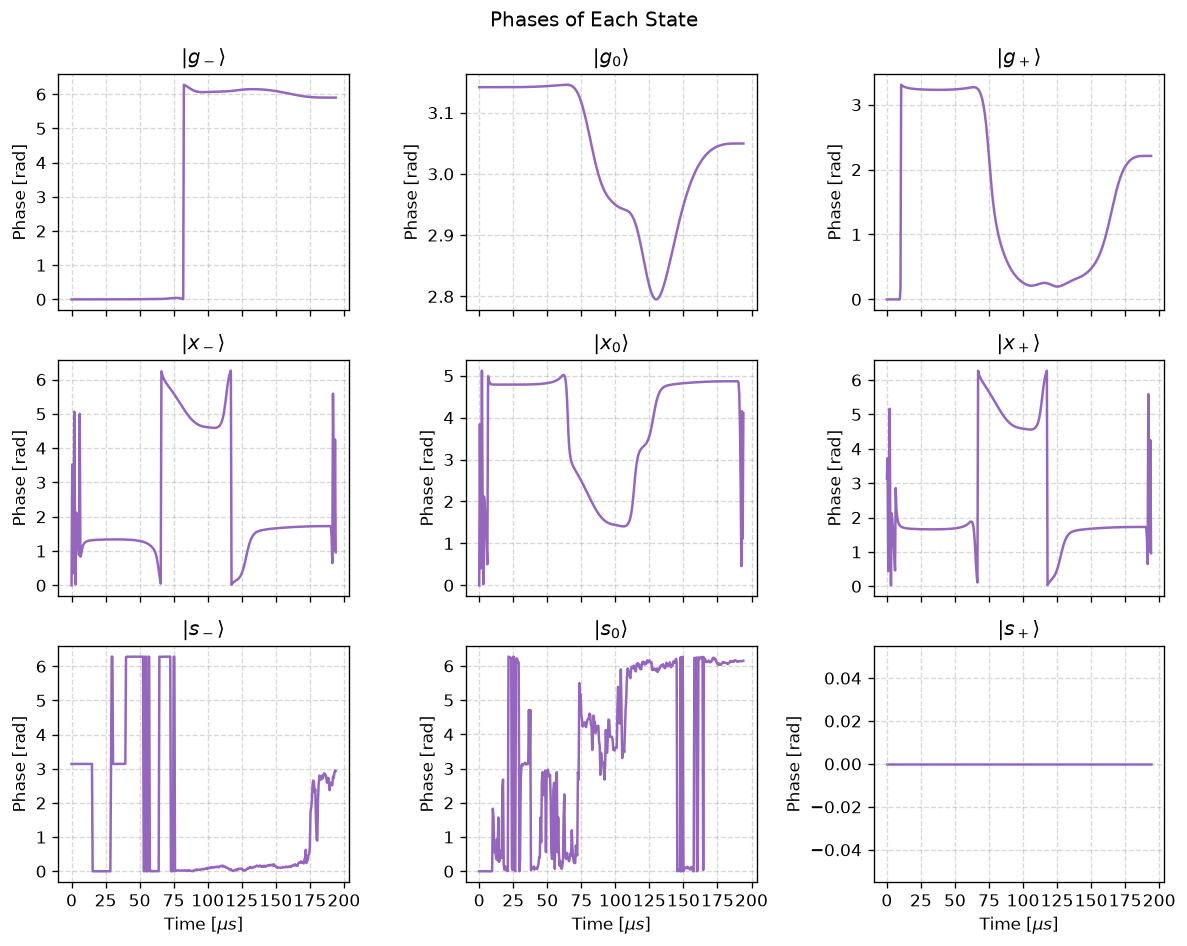

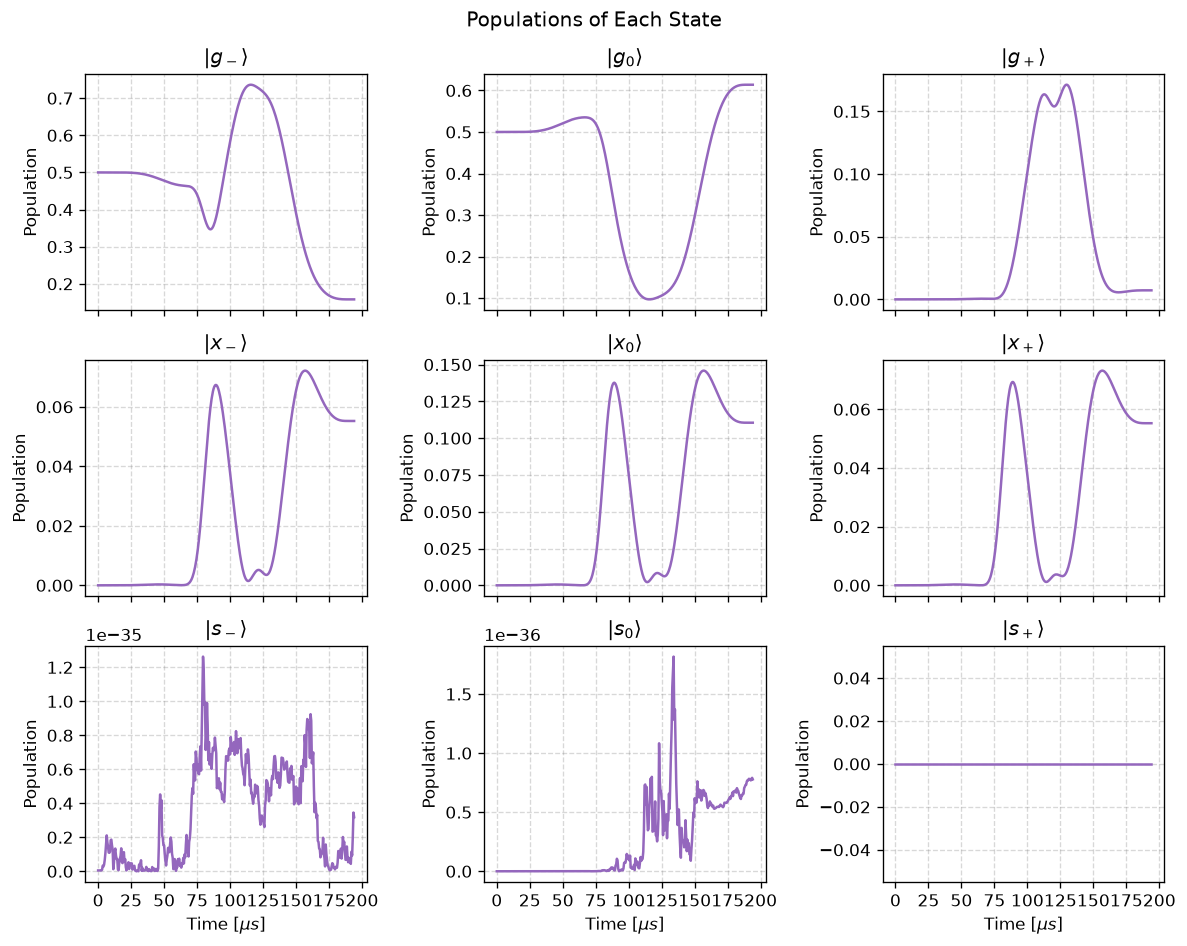

In [424]:
from cmath import polar
from matplotlib.ticker import MultipleLocator

def plot_phase_results(experiment, state, state_label, ax_phi, ax_r):
    r_and_phi = [polar(state.dag() * evolved_state) for evolved_state in experiment.rho] 
    r = np.array(r_and_phi).T[0, :]
    phi = np.array(r_and_phi).T[1, :]

    phi[phi < 0] += 2 * np.pi

    ax_phi.plot(SIMULATION_TIME, phi, color='tab:purple')
    ax_phi.set_ylabel("Phase [rad]")
    ax_phi.set_title(state_label)

    # ax_phi.set_xlabel(r"Time $[\mu s]$")

    ax_r.plot(SIMULATION_TIME, r**2, color='tab:purple')
    ax_r.set_ylabel("Population")
    ax_r.set_title(state_label)

    # ax_r.set_xlabel(r"Time $[\mu s]$")

    return ax_phi, ax_r

all_states = ground_states + bare_excited_states + plus_states
state_labels = [r"$|g_- \rangle$", r"$|g_0 \rangle$", r"$|g_+ \rangle$",
                r"$|x_- \rangle$", r"$|x_0 \rangle$", r"$|x_+ \rangle$",
                r"$|s_- \rangle$", r"$|s_0 \rangle$", r"$|s_+ \rangle$"]
fig_phi, axes_phi = plt.subplots(3, 3, sharex=True, figsize=(10, 8))
fig_r, axes_r = plt.subplots(3, 3, sharex=True, figsize=(10, 8))

flattened_axes_phi = axes_phi.flatten()
flattened_axes_r = axes_r.flatten()

for axis_ind, axis_phi, axis_r, state, state_label in zip(np.arange(len(flattened_axes_phi)), flattened_axes_phi, flattened_axes_r, all_states, state_labels):
    axis_phi, axis_r = plot_phase_results(experiment_C1C2_pulsedsim, state, state_label, axis_phi, axis_r)

    # Turn on the grid
    axis_phi.grid(True, which='both', linestyle='--', color='gray')
    axis_r.grid(True, which='both', linestyle='--', color='gray')

    # Set major grid ticks every 5 units (change number as needed)
    axis_phi.xaxis.set_major_locator(MultipleLocator(25))
    axis_r.xaxis.set_major_locator(MultipleLocator(25))

    if axis_ind in (6, 7, 8):
        axis_phi.set_xlabel(r"Time $[\mu s]$")
        axis_r.set_xlabel(r"Time $[\mu s]$")


fig_phi.suptitle("Phases of Each State")
fig_phi.tight_layout()
fig_phi.show()

fig_r.suptitle("Populations of Each State")
fig_r.tight_layout()
fig_r.show()

## Do Analysis on Final States

In [425]:
def get_final_populations(experiment):
    if type(experiment) == PulsedSim:
        final_populations = np.array([complex(
            experiment.final_state.dag() * 
            proj_op * 
            experiment.final_state)
                for proj_op in list_of_bare_projection_operators])
    elif type(experiment) == Qobj: # passing a state instead of an experiment
        final_populations = np.array([complex(
            experiment.dag() * 
            proj_op * 
            experiment)
                for proj_op in list_of_bare_projection_operators])
    else:
        raise TypeError("Passing incorrect type, must either be PulsedSim or QObj")
    
    # make sure that the populations are real
    if np.sum(final_populations.imag > 1e-12):
        print(final_populations)
        raise ValueError("Populations should not be imaginary")

    return np.abs(final_populations)

In [426]:
final_pops_C1C2 = get_final_populations(experiment_C1C2_pulsedsim)
final_pops_C2C1 = get_final_populations(experiment_C2C1_pulsedsim)
final_pops_no_loops = get_final_populations(experiment_no_loops_pulsedsim)
final_pop_labels = ["C1C2", "C2C1", "No Loops"]
initial_state_pops = get_final_populations(INITIAL_STATE)

for pops, lab in zip([final_pops_C1C2, final_pops_C2C1, final_pops_no_loops], final_pop_labels):
    print(f'Final Populations for {lab} are:')
    print(pops)
    print(f'Sum of All Populations: {np.sum(pops)}')
    print()

print(f'The Initial State Populations are:')
print(initial_state_pops)
print(f'Sum of All Populations: {np.sum(initial_state_pops)}\n')

print(f'Final state differences between C1C2 and C2C1: {final_pops_C2C1 - final_pops_C1C2}')

Final Populations for C1C2 are:
[1.58013262e-01 6.13792974e-01 7.21194684e-03 5.52449766e-02
 1.10491846e-01 5.52449938e-02 6.43392727e-23 5.93761052e-25
 0.00000000e+00]
Sum of All Populations: 1.0000000000000004

Final Populations for C2C1 are:
[6.39009431e-01 1.27954902e-01 1.16314020e-01 2.91806835e-02
 5.83601647e-02 2.91807982e-02 1.27041248e-23 1.59385417e-23
 0.00000000e+00]
Sum of All Populations: 1.0000000000000002

Final Populations for No Loops are:
[4.78773515e-01 5.19577787e-01 4.06355210e-04 3.10603804e-04
 6.21135109e-04 3.10604498e-04 2.33853787e-23 5.98236664e-26
 0.00000000e+00]
Sum of All Populations: 1.0

The Initial State Populations are:
[5.00000000e-01 5.00000000e-01 0.00000000e+00 0.00000000e+00
 5.63064655e-23 1.14863470e-22 4.00215294e-23 0.00000000e+00
 0.00000000e+00]
Sum of All Populations: 0.9999999999999999

Final state differences between C1C2 and C2C1: [ 4.80996169e-01 -4.85838072e-01  1.09102073e-01 -2.60642931e-02
 -5.21316818e-02 -2.60641957e-02 -5.

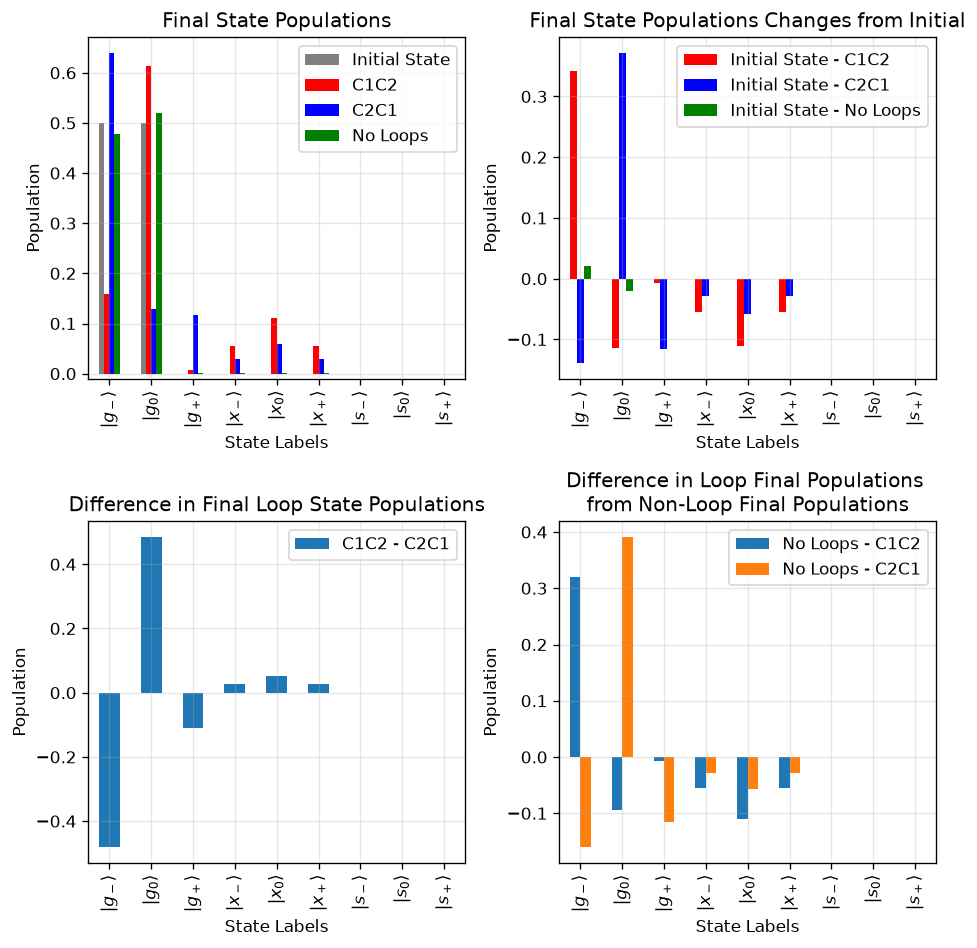

In [427]:
# make a pandas df to make plotting easier
import pandas as pd

population_df = pd.DataFrame({
    "State Labels" : state_labels,
    "Initial State" : initial_state_pops,
    "C1C2" : final_pops_C1C2,
    "C2C1" : final_pops_C2C1,
    "C1C2 - C2C1" : final_pops_C1C2 - final_pops_C2C1,
    "No Loops" : final_pops_no_loops,
    "No Loops - C1C2" : final_pops_no_loops - final_pops_C1C2,
    "No Loops - C2C1" : final_pops_no_loops - final_pops_C2C1,
})

for experiment in ["C1C2", "C2C1", "No Loops"]:
    population_df[f"Initial State - {experiment}"] = population_df["Initial State"] - population_df[experiment]

fig, ax = plt.subplots(2, 2, figsize=(8, 8))

population_df.plot(x="State Labels", y=["Initial State", "C1C2", "C2C1", "No Loops"], 
                   kind='bar', color=['grey', 'red', 'blue', 'green'], ax=ax[0, 0])
ax[0, 0].set_title("Final State Populations")
ax[0, 0].set_ylabel("Population")
ax[0, 0].set_ylim(bottom=-0.01)

population_df.plot(x="State Labels", y=["Initial State - C1C2", "Initial State - C2C1", "Initial State - No Loops"], 
                   kind='bar', color=['red', 'blue', 'green'], ax=ax[0, 1])
ax[0, 1].set_title("Final State Populations Changes from Initial")
ax[0, 1].set_ylabel("Population")

population_df.plot(x="State Labels", y=["C1C2 - C2C1"], 
                   kind='bar', ax=ax[1, 0])
ax[1, 0].set_title("Difference in Final Loop State Populations")
ax[1, 0].set_ylabel("Population")

population_df.plot(x="State Labels", y=["No Loops - C1C2", "No Loops - C2C1"], 
                   kind='bar', ax=ax[1, 1])
ax[1, 1].set_title("Difference in Loop Final Populations \nfrom Non-Loop Final Populations")
ax[1, 1].set_ylabel("Population")

plt.tight_layout()
plt.show()


## Noise Modeling

## Calculate the Berry Phase

In [428]:
# TODO : Make small section for decoherence and noise
# TODO : construct U(C1) and U(C2) from the populations